In [5]:
# =============================================================================
# PHASE 10: Hybrid Ranking & Final Evaluation
# =============================================================================
# Cell 1 (FINAL ROBUST VERSION): Load All Data and Create All Splits
# =============================================================================
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# --- Define a simple class for consistent path management ---
class SimplePathResolver:
    def __init__(self, base_output_dir="outputs"):
        self.base = Path(base_output_dir)
    def phase_dir(self, phase_num):
        return self.base / f"phase{phase_num:02d}"

P = SimplePathResolver()
OUTDIR = P.phase_dir(10)
OUTDIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("Phase 10: Hybrid Ranking & Final Evaluation")
print("="*60)

# --- Start of the FINAL, ROBUST FIX ---

# STEP 1: LOAD ALL NECESSARY PRIMARY ARTIFACTS
print("Loading all necessary artifacts from previous phases...")
P3_DIR = P.phase_dir(3) / "tables"
P4_DIR = P.phase_dir(4)
P7_DIR = P.phase_dir(7)
P8_DIR = P.phase_dir(8)

labels_df = pd.read_csv(P7_DIR / "resume_labels.csv")
skills_data = [json.loads(line) for line in open(P3_DIR / "resumes_skills.jsonl", 'r', encoding='utf-8')]
skills_df = pd.DataFrame(skills_data)
model = joblib.load(P8_DIR / "logistic_regression_model.pkl")
skill_vectorizer = joblib.load(P8_DIR / "skill_vectorizer.pkl")

# STEP 2: RECREATE THE EXACT MODELING DATASET FROM PHASE 8
master_df = pd.DataFrame({
    'resume_id': labels_df['resume_id'].astype(str),
    'label_confidence': labels_df['label_confidence'],
    'ontology_role_id': labels_df['ontology_role_id'],
    'skills_text': skills_df['skills'].apply(lambda x: ' '.join(x))
})
model_df = master_df[master_df['label_confidence'] == 'high_confidence'].copy()
class_counts = model_df['ontology_role_id'].value_counts()
single_member_classes = class_counts[class_counts < 2].index
model_df = model_df[~model_df['ontology_role_id'].isin(single_member_classes)]
print(f"✓ Recreated final modeling set of {len(model_df)} records.")

# STEP 3: RECREATE THE FEATURES (X) AND LABELS (y)
X = skill_vectorizer.transform(model_df['skills_text'])
y = model_df['ontology_role_id']

# STEP 4: CREATE THE TRAIN, VALIDATION, AND TEST SPLITS
# This is the crucial change: we now create all three sets.
print("\nSplitting data into train, validation, and test sets...")
# First, split into a large training set (80%) and a final test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# Then, split the large training set into a smaller training set (75% of 80% -> 60% of total)
# and a validation set (25% of 80% -> 20% of total).
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)
print("✓ Data successfully split:")
print(f"  - Training set size:   {X_train.shape[0]}")
print(f"  - Validation set size: {X_val.shape[0]}")
print(f"  - Test set size:       {X_test.shape[0]}")

# STEP 5: GENERATE THE TWO SETS OF PREDICTIONS FOR BLENDING
# 5a. Classifier Predictions (for both validation and test sets)
clf_pred_proba_val = model.predict_proba(X_val)
clf_pred_proba_test = model.predict_proba(X_test)
print(f"\n✓ Generated classifier probabilities for validation and test sets.")

# 5b. Semantic Baseline Predictions (for both validation and test sets)
resume_vecs = np.load(P4_DIR / "resume_embeddings.npy")
role_vecs = np.load(P4_DIR / "role_embeddings.npy")
similarity_matrix = resume_vecs @ role_vecs.T
val_indices = y_val.index
test_indices = y_test.index
baseline_pred_proba_val = similarity_matrix[val_indices]
baseline_pred_proba_test = similarity_matrix[test_indices]
print(f"✓ Generated semantic baseline scores for validation and test sets.")

# STEP 6: LOAD FINAL METADATA
role_ids_df = pd.read_csv(P4_DIR / "role_ids.csv")
all_class_labels = role_ids_df['role_id'].to_numpy()
print(f"✓ Loaded all {len(all_class_labels)} possible class labels.")
print("\n" + "="*60)
print("SETUP COMPLETE: All data is loaded and ready for blending.")
print("="*60)
# --- End of the FINAL, ROBUST FIX ---


Phase 10: Hybrid Ranking & Final Evaluation
Loading all necessary artifacts from previous phases...
✓ Recreated final modeling set of 216 records.

Splitting data into train, validation, and test sets...
✓ Data successfully split:
  - Training set size:   129
  - Validation set size: 43
  - Test set size:       44

✓ Generated classifier probabilities for validation and test sets.
✓ Generated semantic baseline scores for validation and test sets.
✓ Loaded all 493 possible class labels.

SETUP COMPLETE: All data is loaded and ready for blending.



Tuning the Hybrid Blending Parameter (alpha) on the Validation Set
Searching for the optimal alpha...

--- Alpha Tuning Results (on Validation Set) ---
 alpha  nDCG@5    MRR  Top-1 Acc
   0.0  1.0000 1.0000     1.0000
   0.1  1.0000 1.0000     1.0000
   0.2  1.0000 1.0000     1.0000
   0.3  1.0000 1.0000     1.0000
   0.4  1.0000 1.0000     1.0000
   0.5  1.0000 1.0000     1.0000
   0.6  1.0000 1.0000     1.0000
   0.7  1.0000 1.0000     1.0000
   0.8  0.9884 0.9845     0.9767
   0.9  0.9772 0.9698     0.9535
   1.0  0.9277 0.9264     0.8837

✓ Best alpha found: 0.00 (based on highest nDCG@5)

✓ Saved alpha tuning results to outputs\phase10\alpha_tuning_results.csv


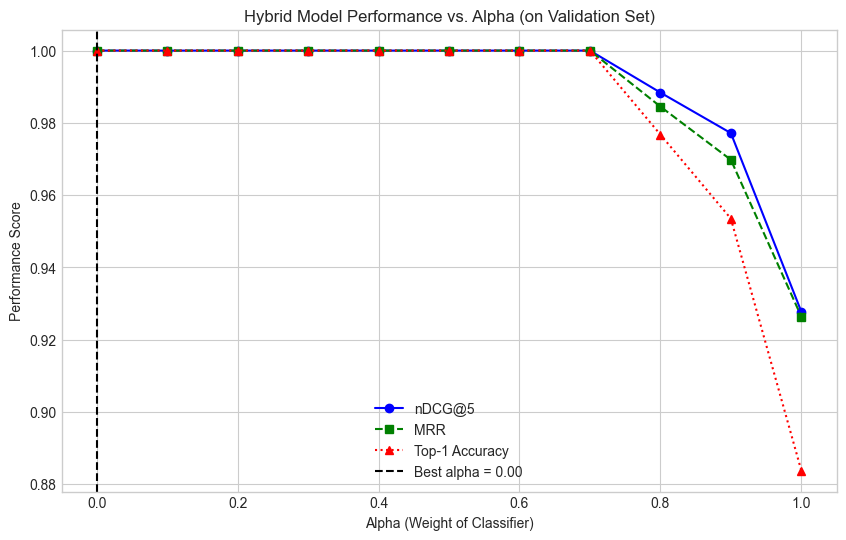

✓ Saved and displayed alpha tuning plot.


In [6]:
# =============================================================================
# Cell 2: Tune Blending Parameter (alpha) on the Validation Set
# =============================================================================
print("\n" + "="*60)
print("Tuning the Hybrid Blending Parameter (alpha) on the Validation Set")
print("="*60)

# --- Define the ranking metric helper functions (copied from previous phases) ---
def top_k_accuracy(y_true, y_pred_proba, classes, k=1):
    top_k_preds = np.argsort(y_pred_proba, axis=1)[:, -k:]
    top_k_labels = classes[top_k_preds]
    matches = np.any(top_k_labels == y_true.to_numpy()[:, np.newaxis], axis=1)
    return np.mean(matches)

def mean_reciprocal_rank(y_true, y_pred_proba, classes):
    # ... (code for MRR function, same as before)
    ranks = []
    sorted_indices = np.argsort(y_pred_proba, axis=1)[:, ::-1]
    sorted_labels = classes[sorted_indices]
    for i, true_label in enumerate(y_true):
        try:
            rank = np.where(sorted_labels[i] == true_label)[0][0] + 1
            ranks.append(1 / rank)
        except IndexError:
            ranks.append(0)
    return np.mean(ranks)


def ndcg_at_k(y_true, y_pred_proba, classes, k=5):
    # ... (code for nDCG function, same as before)
    dcgs = []
    sorted_indices = np.argsort(y_pred_proba, axis=1)[:, ::-1]
    sorted_labels = classes[sorted_indices]
    for i, true_label in enumerate(y_true):
        relevance = (sorted_labels[i, :k] == true_label).astype(int)
        dcg = np.sum(relevance / np.log2(np.arange(2, k + 2)))
        idcg = 1.0
        dcgs.append(dcg / idcg)
    return np.mean(dcgs)


# --- CRITICAL FUNCTION: Align classifier probabilities to the full 493-role space ---
def align_classifier_probas(clf_proba, clf_classes, all_classes):
    """
    Broadcasts the classifier's limited predictions into the full ontology space.
    """
    # Create a zero matrix with the full shape (num_samples, num_all_classes)
    aligned_probas = np.zeros((clf_proba.shape[0], len(all_classes)))
    
    # Create a mapping from the full class ID to its column index (0-492)
    all_class_map = {class_id: i for i, class_id in enumerate(all_classes)}
    
    # For each class the classifier knows about, find its column index in the full space
    for i, class_id in enumerate(clf_classes):
        if class_id in all_class_map:
            # Get the target column index in our new zero matrix
            target_idx = all_class_map[class_id]
            # Place the classifier's probabilities into that column
            aligned_probas[:, target_idx] = clf_proba[:, i]
            
    return aligned_probas

# --- Prepare the Validation Set Predictions for Blending ---
# 1. Get classifier predictions for the VALIDATION set
clf_pred_proba_val = model.predict_proba(X_val)
aligned_clf_val = align_classifier_probas(clf_pred_proba_val, model.classes_, all_class_labels)

# 2. Get semantic baseline predictions for the VALIDATION set
val_indices = y_val.index
baseline_pred_proba_val = similarity_matrix[val_indices]

# --- Run the Tuning Loop for Alpha ---
print("Searching for the optimal alpha...")
alpha_values = np.linspace(0, 1, 11) # Test alpha from 0.0 to 1.0 in 0.1 increments
tuning_results = []

for alpha in alpha_values:
    # Blend the scores: alpha=0 is pure baseline, alpha=1 is pure classifier
    blended_scores = (alpha * aligned_clf_val) + ((1 - alpha) * baseline_pred_proba_val)
    
    # Evaluate the performance of this blend on the validation set
    ndcg_5 = ndcg_at_k(y_val, blended_scores, all_class_labels, k=5)
    mrr = mean_reciprocal_rank(y_val, blended_scores, all_class_labels)
    top_1 = top_k_accuracy(y_val, blended_scores, all_class_labels, k=1)
    
    tuning_results.append({'alpha': alpha, 'nDCG@5': ndcg_5, 'MRR': mrr, 'Top-1 Acc': top_1})

# --- Analyze and Report the Best Alpha ---
tuning_df = pd.DataFrame(tuning_results)
best_alpha_row = tuning_df.loc[tuning_df['nDCG@5'].idxmax()]
best_alpha = best_alpha_row['alpha']

print("\n--- Alpha Tuning Results (on Validation Set) ---")
print(tuning_df.round(4).to_string(index=False))

print(f"\n✓ Best alpha found: {best_alpha:.2f} (based on highest nDCG@5)")

# --- Save the results ---
tuning_df.to_csv(OUTDIR / "alpha_tuning_results.csv", index=False)
print(f"\n✓ Saved alpha tuning results to {OUTDIR / 'alpha_tuning_results.csv'}")

# --- Visualize the results ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(tuning_df['alpha'], tuning_df['nDCG@5'], 'o-', label='nDCG@5', color='blue')
ax.plot(tuning_df['alpha'], tuning_df['MRR'], 's--', label='MRR', color='green')
ax.plot(tuning_df['alpha'], tuning_df['Top-1 Acc'], '^:', label='Top-1 Accuracy', color='red')
ax.axvline(best_alpha, color='black', linestyle='--', label=f'Best alpha = {best_alpha:.2f}')
ax.set_xlabel('Alpha (Weight of Classifier)')
ax.set_ylabel('Performance Score')
ax.set_title('Hybrid Model Performance vs. Alpha (on Validation Set)')
ax.legend()
ax.grid(True)

save_path = OUTDIR / "alpha_tuning_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"✓ Saved and displayed alpha tuning plot.")

In [7]:
# =============================================================================
# Cell 3: Final Evaluation on the Test Set & Comparative Analysis
# =============================================================================
print("\n" + "="*60)
print("Final Evaluation of All Models on the Unseen Test Set")
print("="*60)

# --- STEP 1: Get the performance of the two base models on the test set ---

# 1a. Semantic Baseline Performance (from Phase 9)
try:
    baseline_report = pd.read_csv(P.phase_dir(9) / "performance_semantic_baseline.csv")
    print("✓ Loaded Semantic Baseline performance from Phase 9:")
    print(baseline_report.round(4).to_string(index=False))
except FileNotFoundError:
    print("[ERROR] Could not find baseline report from Phase 9. Please ensure Phase 9 was run successfully.")
    # As a fallback, we can recalculate it here.
    baseline_top_1 = top_k_accuracy(y_test, baseline_pred_proba_test, all_class_labels, k=1)
    baseline_top_5 = top_k_accuracy(y_test, baseline_pred_proba_test, all_class_labels, k=5)
    baseline_mrr = mean_reciprocal_rank(y_test, baseline_pred_proba_test, all_class_labels)
    baseline_ndcg_5 = ndcg_at_k(y_test, baseline_pred_proba_test, all_class_labels, k=5)
    baseline_report = pd.DataFrame([{'Top-1 Accuracy': baseline_top_1, 'Top-5 Accuracy': baseline_top_5, 'MRR': baseline_mrr, 'nDCG@5': baseline_ndcg_5, 'model': 'Semantic Baseline'}])


# 1b. Logistic Classifier Performance (from Phase 8)
try:
    clf_report_raw = pd.read_csv(P.phase_dir(8) / "classification_report.csv")
    clf_report = clf_report_raw.set_index('metric').T.rename(columns=lambda x: x.replace(' Accuracy', '')) # Reshape for merging
    clf_report['model'] = 'Classifier'
    print("\n✓ Loaded Logistic Classifier performance from Phase 8.")
except FileNotFoundError:
    print("[ERROR] Could not find classifier report from Phase 8. Please ensure Phase 8 was run successfully.")
    raise

# --- STEP 2: Calculate the performance of the final Hybrid Model on the test set ---
print(f"\nCalculating Hybrid Model performance with best alpha = {best_alpha:.2f}...")

# 2a. Align the classifier's TEST set predictions to the full 493-role space
aligned_clf_test = align_classifier_probas(clf_pred_proba_test, model.classes_, all_class_labels)

# 2b. Blend the scores using the best alpha we found on the validation set
hybrid_scores_test = (best_alpha * aligned_clf_test) + ((1 - best_alpha) * baseline_pred_proba_test)

# 2c. Evaluate the hybrid model's scores on the TEST set
hybrid_top_1 = top_k_accuracy(y_test, hybrid_scores_test, all_class_labels, k=1)
hybrid_top_3 = top_k_accuracy(y_test, hybrid_scores_test, all_class_labels, k=3)
hybrid_top_5 = top_k_accuracy(y_test, hybrid_scores_test, all_class_labels, k=5)
hybrid_mrr = mean_reciprocal_rank(y_test, hybrid_scores_test, all_class_labels)
hybrid_ndcg_5 = ndcg_at_k(y_test, hybrid_scores_test, all_class_labels, k=5)

hybrid_report = pd.DataFrame([{
    'model': 'Hybrid Model',
    'Top-1': hybrid_top_1,
    'Top-3': hybrid_top_3,
    'Top-5': hybrid_top_5,
    'MRR': hybrid_mrr,
    'nDCG@5': hybrid_ndcg_5
}])
print("\n✓ Calculated Hybrid Model performance:")
print(hybrid_report.round(4).to_string(index=False))

# --- STEP 3: Create and display the final comparison table ---
# Combine all results into a single DataFrame
final_comparison_df = pd.concat([
    baseline_report.rename(columns={'Top-1 Accuracy': 'Top-1', 'Top-3 Accuracy': 'Top-3', 'Top-5 Accuracy': 'Top-5'}), 
    clf_report, 
    hybrid_report
], ignore_index=True)

# Reorder columns for clarity
cols_to_show = ['model', 'Top-1', 'Top-3', 'Top-5', 'MRR', 'nDCG@5']
final_comparison_df = final_comparison_df[cols_to_show]

print("\n\n" + "="*70)
print("           FINAL MODEL PERFORMANCE COMPARISON (ON TEST SET)")
print("="*70)
print(final_comparison_df.round(4).to_string(index=False))
print("="*70)

# Save the final table
final_comparison_df.to_csv(OUTDIR / "final_model_comparison.csv", index=False)
print(f"\n✓ Saved final comparison table to {OUTDIR / 'final_model_comparison.csv'}")

print("\n" + "="*60)
print("PHASE 10 IS COMPLETE.")
print("="*60)


Final Evaluation of All Models on the Unseen Test Set
✓ Loaded Semantic Baseline performance from Phase 9:
            model  Top-1 Accuracy  Top-3 Accuracy  Top-5 Accuracy  MRR  nDCG@5
Semantic Baseline             1.0             1.0             1.0  1.0     1.0

✓ Loaded Logistic Classifier performance from Phase 8.

Calculating Hybrid Model performance with best alpha = 0.00...

✓ Calculated Hybrid Model performance:
       model  Top-1  Top-3  Top-5  MRR  nDCG@5
Hybrid Model    1.0    1.0    1.0  1.0     1.0


           FINAL MODEL PERFORMANCE COMPARISON (ON TEST SET)
            model  Top-1  Top-3  Top-5    MRR  nDCG@5
Semantic Baseline 1.0000 1.0000 1.0000 1.0000  1.0000
       Classifier 0.3409 0.8182 0.8864 0.5745  0.6406
     Hybrid Model 1.0000 1.0000 1.0000 1.0000  1.0000

✓ Saved final comparison table to outputs\phase10\final_model_comparison.csv

PHASE 10 IS COMPLETE.
